<a href="https://colab.research.google.com/github/joseferbis-cell/PLs-ADFM/blob/main/practice_2_a_parameterized_nns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/vischia/adfm_2024-2025/blob/master/practice_2_a_parameterized_nns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Datos en Física Moderna

(C)2025 Pietro Vischia, vischia@uniovi.es

## PL 2: machine learning paramétrico

In this practice, you'll implement the parameterized machine learning algorithm devised by Baldi et al., [1601.07913](https://arxiv.org/abs/1601.07913)

In [ ]:
# Uncomment and run this if you are running on Colab (remove only the "#", keep the "!").
# You can run it anyway, but it will do nothing if you have already installed all dependencies
# (and it will take some time to tell you it is not gonna do anything)


from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/"
! git clone https://github.com/vischia/atdtf.git
%cd atdtf
!pwd
!ls
!pip install livelossplot shap

Mounted at /content/drive
/content/drive/MyDrive
fatal: destination path 'atdtf' already exists and is not an empty directory.
/content/drive/MyDrive/atdtf
/content/drive/MyDrive/atdtf
data			data_for_practica2.zip.1  figs
databases		data_for_practica2.zip.2  PL1_sesgo_inductivo.ipynb
data_for_practica2	data_for_practica2.zip.3  PL2_parameterized_nns.ipynb
data_for_practica2.zip	data_for_practica2.zip.4  README.md


In [ ]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import glob
import os
import re
import math
import socket
import json
import pickle
import gzip
import copy
import array
import numpy as np
import numpy.lib.recfunctions as recfunc

from scipy.optimize import newton
from scipy.stats import norm

import datetime
from timeit import default_timer as timer

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.tree import export_graphviz
from sklearn.inspection import permutation_importance
try:
    # See #1137: this allows compatibility for scikit-learn >= 0.24
    from sklearn.utils import safe_indexing
except ImportError:
    from sklearn.utils import _safe_indexing

from livelossplot import PlotLossesKeras

import torch

import pandas as pd


In [ ]:
INPUT_FOLDER = './'
HAVE_GPU = True


We will use the [HEP-mass dataset](http://archive.ics.uci.edu/ml/datasets/hepmass) hosted by UCIrvine together with many other datasets used to test machine learning applications.

This dataset provides top pair production events as a background, and the classification task is to separate them from events generated by a high-mass resonance (masses of 500--1000 GeV). The larger the mass, the easiest the prediction task.

The label is 1 for signal, and 0 for background. There are 27 normalized features, divided into 22 low-level ones and 5 high-level ones. Because of time constraints, we won't explore the topic of pitting low-level and high-level features against each other or of mixing them, but you are encouraged to play with them later.

<img src="https://github.com/vischia/adfm_2024-2025/blob/master/figs/hepmass.png?raw=1" alt="masses from 1601.07913" style="width:50%;"/>

(figure from [1601.07913](https://arxiv.org/abs/1601.07913))

You can download the data from:

[https://www.hep.uniovi.es/vischia/adfm/](https://www.hep.uniovi.es/vischia/adfm/)

by hand or by running:

In [ ]:
downloadMinidata=True

if downloadMinidata:
    !mkdir data
    !cd data
    !wget https://www.hep.uniovi.es/vischia/adfm/data_for_practica2.zip
    !unzip data_for_practica2.zip
    !cd ..

mkdir: cannot create directory ‘data’: File exists
--2025-11-13 14:28:17--  https://www.hep.uniovi.es/vischia/adfm/data_for_practica2.zip
Resolving www.hep.uniovi.es (www.hep.uniovi.es)... 156.35.212.25
Connecting to www.hep.uniovi.es (www.hep.uniovi.es)|156.35.212.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 57367876 (55M) [application/zip]
Saving to: ‘data_for_practica2.zip.5’

data_for_practica2. 100%[===================>]  54.71M  33.1MB/s    in 1.7s    

2025-11-13 14:28:19 (33.1 MB/s) - ‘data_for_practica2.zip.5’ saved [57367876/57367876]

Archive:  data_for_practica2.zip
replace data_for_practica2/not1000_750_test_small.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: data_for_practica2/not1000_750_test_small.csv  
  inflating: data_for_practica2/not1000_750_train_small.csv  
  inflating: data_for_practica2/not1000_750_test_large.csv  
  inflating: data_for_practica2/not1000_750_train_large.csv  
  inflating: data_for_practica2/1000_train

In [ ]:
# Do not set these to True in the live tutorial,
# otherwise you will clog the conference venue connection for nothing.
# The skimmed files are already included in this repository

createLowMass=False
createHighMass=False

if createLowMass:
    ! wget http://archive.ics.uci.edu/ml/machine-learning-databases/00347/not1000_train.csv.gz
    ! wget http://archive.ics.uci.edu/ml/machine-learning-databases/00347/not1000_test.csv.gz
    cols=["label", "f0", "f1", "f2", "f3", "f4", "f5", "f6", "f7", "f8", "f9", "f10", "f11", "f12", "f13",
          "14f", "15f", "f16", "f17", "f18", "f19", "f20", "f21", "f22", "f23", "f24", "f25", "f26", "mass"]

    train_set = pd.read_csv('./not1000_train.csv.gz', index_col=False, names=cols, header=0)
    test_set = pd.read_csv('./not1000_test.csv.gz', index_col=False, names=cols, header=0)

    # Here we exploit the fact that the background has an assigned random mass sampled from
    # the same set than that of the signal. Therefore we can just require the mass to be 500
    # without having to check for the signal and background label.
    # A final test ensures the amount of events is approximately the same.

    # In the data set, for some reason the "mass 500" is encoded as 499.999969, but "==499.999969" does not
    # match any entry. We will therefore use "<501" to select the events with mass=500

    train_set=train_set[train_set['mass']<501]
    test_set=test_set[test_set['mass']<501]

    print('Full train', len(train_set),
          len(train_set[train_set['label']==1]),
          len(train_set[train_set['label']==0]))
    print('Full test', len(test_set),
          len(test_set[test_set['label']==1]),
          len(test_set[test_set['label']==0]))

    train_set_temp=train_set.head(10000)
    test_set_temp=test_set.head(10000)

    train_set_temp.to_csv('data/not1000_train_medium.csv')
    test_set_temp.to_csv('data/not1000_test_medium.csv')


    train_set_temp=train_set.head(1000)
    test_set_temp=test_set.head(1000)

    train_set_temp.to_csv('data/not1000_train_small.csv')
    test_set_temp.to_csv('data/not1000_test_small.csv')


if createHighMass: # Not needed, I included the small and medium sets in the github repository

    ! wget http://archive.ics.uci.edu/ml/machine-learning-databases/00347/1000_train.csv.gz
    ! wget http://archive.ics.uci.edu/ml/machine-learning-databases/00347/1000_test.csv.gz
    # This needs to be run only once
    cols=[label_name, "f0", "f1", "f2", "f3", "f4", "f5", "f6", "f7", "f8", "f9", "f10", "f11", "f12", "f13", "14f", "15f", "f16", "f17", "f18", "f19", "f20", "f21", "f22", "f23", "f24", "f25", "f26"]
    train_set = pd.read_csv('./1000_train.csv.gz', index_col=False, names=cols, header=0)
    test_set = pd.read_csv('./1000_test.csv.gz', index_col=False, names=cols, header=0)

    # Randomly pick 10000 events from the full data set
    train_set_temp=train_set.head(10000)
    test_set_temp=test_set.head(10000)

    train_set_temp.to_csv('data/1000_train_medium.csv')
    test_set_temp.to_csv('data/1000_test_medium.csv')

    # Randomly pick 1000 events from the full data set
    train_set_temp=train_set.head(1000)
    test_set_temp=test_set.head(1000)

    train_set_temp.to_csv('data/1000_train_small.csv')
    test_set_temp.to_csv('data/1000_test_small.csv')


In [ ]:
# Load the chosen set
train_set=pd.read_csv('data_for_practica2/not1000_750_train_medium.csv', index_col=False)
test_set=pd.read_csv('data_for_practica2/not1000_750_test_medium.csv', index_col=False)

# Drop mass info, if needed (the "1000..." files don't have a 'mass' column)
if 'mass' in train_set.columns:
    train_set=train_set.drop(['mass'], axis=1)
    test_set=test_set.drop(['mass'], axis=1)
train_set.head()

,Unnamed: 0,label,f0,f1,f2,f3,f4,f5,f6,f7,...,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26
0,1,1.0,-1.401979,-0.942620,1.049402,1.637764,1.681190,-0.005984,0.733926,-0.476641,...,-0.815440,-0.822903,0.156014,-0.197154,1.743123,0.361093,-0.941934,0.026127,1.396366,-0.123928
1,12,0.0,-0.646328,0.132367,0.864149,0.596158,0.266139,-1.054221,-0.801212,0.231854,...,1.226331,-1.368451,-0.189723,-1.710976,-0.573682,-0.800589,-0.594036,-0.377533,-0.113845,-1.300184
2,13,1.0,-0.093261,0.168337,1.287353,0.319592,-1.359426,1.574625,0.988875,-0.268706,...,-0.815440,1.634929,-0.067125,-1.548938,1.743123,-0.015264,-0.080968,0.756942,0.879847,0.218808
3,16,1.0,1.205673,1.103310,-1.132657,-1.284128,-0.823548,0.850488,0.943595,0.516031,...,1.226331,0.383688,-0.162711,1.030514,-0.573682,-0.739276,-0.147738,-0.270474,-0.256237,0.318978
4,19,0.0,-1.134711,1.257473,-0.419845,-0.848054,-1.568315,-1.054221,-0.144344,-0.077036,...,-0.815440,-0.278497,0.340343,0.306618,-0.573682,-0.384413,-0.364842,-0.309805,-0.673690,-0.957803


In [ ]:
print('Training set has', len(train_set), 'entries (', len(train_set[train_set['label']==1]), 'signal entries, ',
      len(train_set[train_set['label']==0]), ' background entries)')

Training set has 10000 entries ( 5002 signal entries,  4998  background entries)


### Split the data set into training and test set

When we train a machine learning algorithm, we are trying to solve an interpolation problem (*find the function of the input features that provides the best approximation of the true function*) by also requiring that the solution generalizes sufficiently well (*the interpolating function must also predict correctly the value of the true function for new, unseen data*).


When we have a labelled dataset, we will therefore split it into: a *training set*, which we will use to train the machine learning algorithm; a *test set*, which we will use to evaluate the performance of the algorithm for various realizations of the algorithm (e.g. tuning hyperparameters); and an *application set*, which are the data we are really interested in studying in the end.

For many applications, when the amount of hyperparameters tuning is moderate, application set and test set can be collapsed into a single set (usually called *test set*). This is what we will do in this tutorial.

![Blah](https://github.com/vischia/adfm_2024-2025/blob/master/figs/trainingNetwork.png?raw=1)

(Image: P. Vischia, [doi:10.5281/zenodo.6373442](https://doi.org/10.5281/zenodo.6373442))

For the data set that we have loaded, we don't need to do any splitting, because the data set is already split.
If our data set needed to be split, we would do something like



In [ ]:
# X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.33, random_state=42)


### Inspect the data set

The first and most important thing to do, when developing a ML application, is to inspect the data set.

Looking at the data is crucial, because it may reveal the presence of malformed or missing data (e.g. when one feature has been filled with meaningless values for some or all of the data points) and may hint at whether it is necessary to preprocess the data.

In [ ]:
# Visualize dataset

### Librería de visualización
import seaborn as sns
sns.set()                 # estilo por defecto

0.13.2


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.2`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.2`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.2`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  func(x=vector, **plot_kwargs)
/usr/local/lib/p

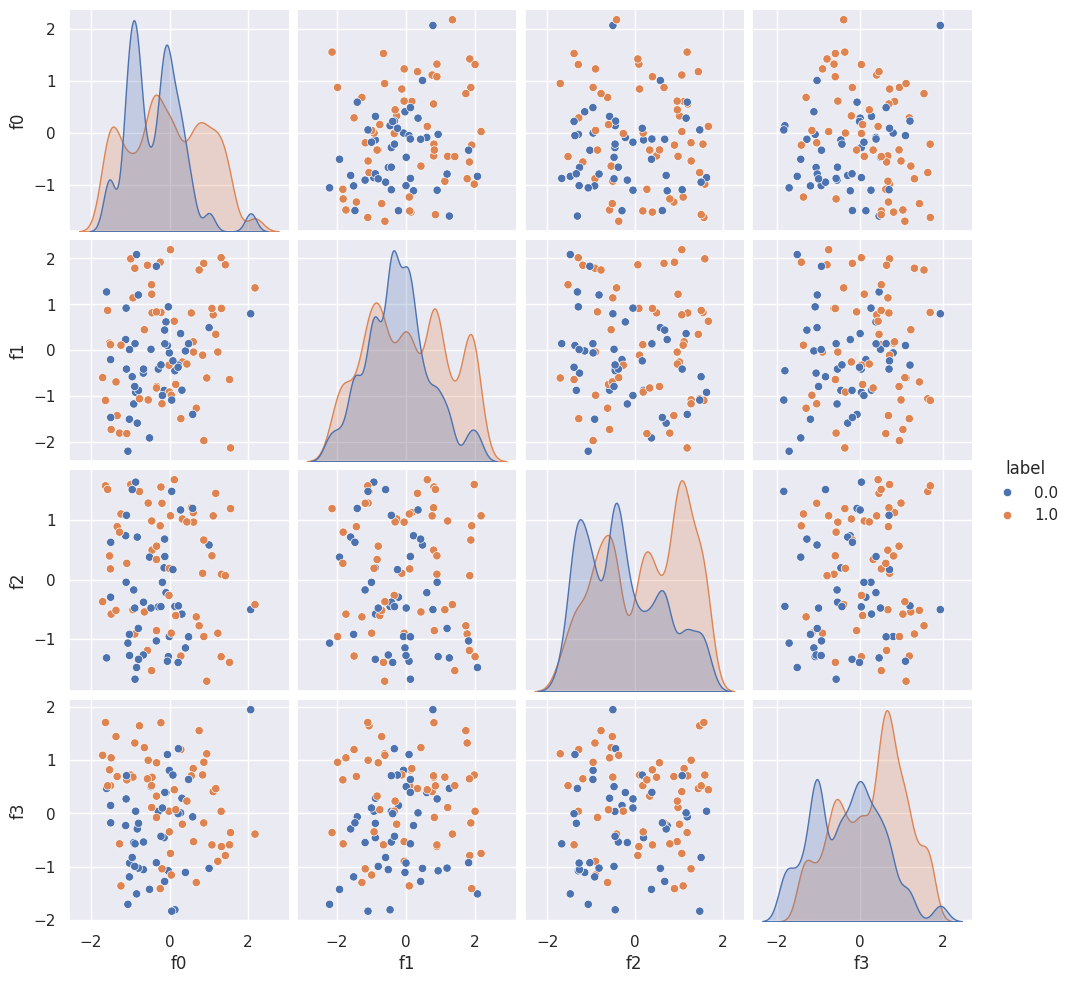

In [ ]:
print(sns.__version__)    # versión

### Ejemplo para las primeras 5 columnas
cols_to_plot = train_set.columns[1:6].tolist()

pp=sns.pairplot(data=train_set.sample(100)[cols_to_plot], hue='label', diag_kws={'bw': 0.2})
#sns.pairplot(train_set.sample(100))
plt.show()

In [ ]:
pp.map_lower(sns.kdeplot, levels=4, color=".2")
plt.show(sns)

#### Correlation matrices

Take a look at the correlation matrices

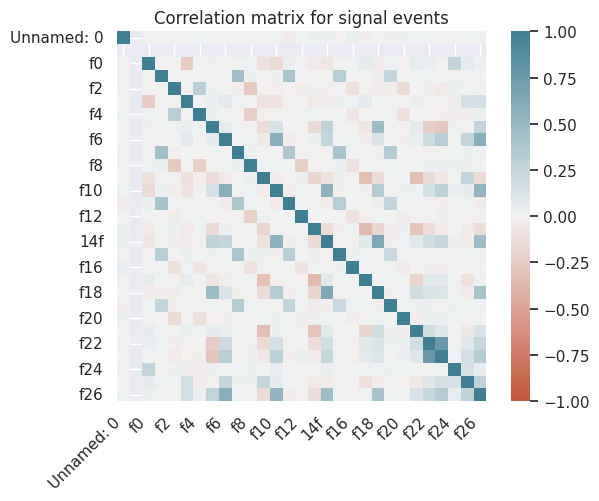

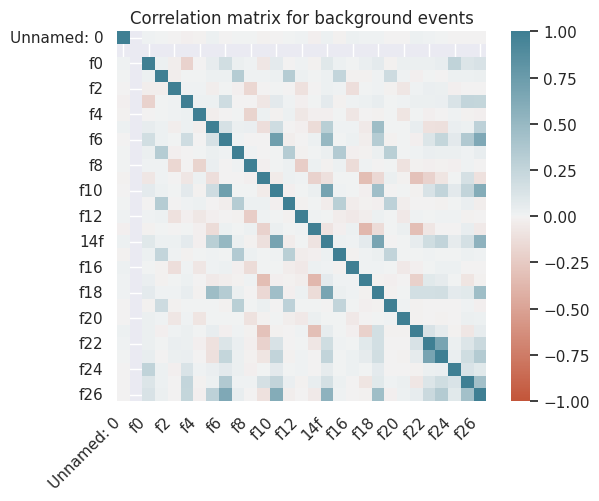

In [ ]:
def corrmatrix(corr, label):
    ax = sns.heatmap(
        corr,
        vmin=-1., vmax=1., center=0.,
        cmap=sns.diverging_palette(20., 220., n=200, as_cmap=True),
        square=True
    )
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment='right'
    );

    ax.set_title('Correlation matrix for %s events' % label)

    plt.show()


corrmatrix(train_set[train_set['label']==1.].corr(), 'signal')
corrmatrix(train_set[train_set['label']==0.].corr(), 'background')


### Preprocess the data

Normally you'd check if it makes sense to preprocess the input features.

Unfortunately, **the HEPmass dataset contains pre-normalized features, so it doesn't make sense to renormalize them**.
You are welcome to check the effect of scalers on other datasets. For reference, you can check [this `scikit-learn` post](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html) for the python code to apply scalers to input features.

#### Build a parametric neural network

Following the instructions below

# 1) Definimos "Fondo" como "standard model tt", y "Señal" como "partícula de nueva física con masa M=xxx que se desintegra a tt"

In [57]:
### Paquetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


### Definiciones físicas
"""
Definimos:
- FONDO (Background): "Standard Model tt" - producción de pares top-antitop
- SEÑAL (Signal): "Partícula de nueva Física con masa M que se desintegra a tt"

En nuestro dataset:
- label = 1 -> Señal (nueva Física)
- label = 0 -> Fondo (tt)

Las masas disponibles en nuestros datos:
- ~500 GeV (archivos "not1000_*")
- ~750 GeV (archivos "not1000_750_*")
- ~1000 GeV (archivos "1000_*")
"""

### Cargamos los datasets
train_500 = pd.read_csv('data_for_practica2/not1000_train_medium.csv')
test_500 = pd.read_csv('data_for_practica2/not1000_test_medium.csv')
train_750 = pd.read_csv('data_for_practica2/not1000_750_train_medium.csv')
test_750 = pd.read_csv('data_for_practica2/not1000_750_test_medium.csv')
train_1000 = pd.read_csv('data_for_practica2/1000_train_medium.csv')
test_1000 = pd.read_csv('data_for_practica2/1000_test_medium.csv')

# Verificar la estructura de cada dataset (que las masas correspondan)
for mass, data in datasets.items():
    print(f"\n----- {mass} -----")
    train_data = data['train']
    test_data = data['test']

    print(f"Train: {len(train_data)} eventos "
          f"({len(train_data[train_data['label']==1])} señal, "
          f"{len(train_data[train_data['label']==0])} fondo)")
    print(f"Test: {len(test_data)} eventos "
          f"({len(test_data[test_data['label']==1])} señal, "
          f"{len(test_data[test_data['label']==0])} fondo)")

    ### Eliminamos la columna de la masa si la tiene
    if 'mass' in train_data.columns:
        data['train'] = train_data.drop('mass', axis=1)
        data['test'] = test_data.drop('mass', axis=1)


### Definimos una función para entrenar modelos básicos:
def modelo_simple(input_dim):
  model = nn.Sequential(
      nn.Linear(input_dim, 64), # dense layer(número de aracteristica, número de neuronas)
      nn.ReLU(), # función e activación
      nn.Dropout(0.3), # regularización(apaga el 30% de las neuronas durantte el entrenamiento)
      nn.Linear(64,32),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(32,1), # la salida es binaria (1)
      nn.Sigmoid()) # para normalizar, devuelve así un valor entre 0 y 1
  return model

# 4. Función para entrenar modelo
def entrenar_modelo(model, X_train, y_train, X_test, y_test, epochs=15, batch_size=32):
    """Entrena y evalúa un modelo PyTorch"""

    # Convertir a tensores (dataframes -> tensores PyTorch)
    X_train_tensor = torch.FloatTensor(X_train.values)
    y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test.values)
    y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

    # DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # empareja características y etiquetas
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # divide en lotes y mezcla datos

    # Optimizador y pérdida
    optimizer = optim.Adam(model.parameters(), lr=0.001) # optimizador adaptativo
    criterion = nn.BCELoss() # Binary Cross Entropy para clasificación binaria

    # Bucle de entrenamiento
    model.train() # Activa dropout y cálculo de gradientes
    for epoch in range(epochs):
        total_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad() # limpia gradientes anteriores
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward() # Calcula gradientes (derivadas)
            optimizer.step() # Actualiza pesos usando gradientes
            total_loss += loss.item()

        # cada 5 épocas imprimimos
        if (epoch + 1) % 5 == 0:
            avg_loss = total_loss / len(train_loader)
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    # Evaluación final
    model.eval() # Desactiva dropout
    with torch.no_grad(): # Acelera evalucaión (sin gradientes)
        test_predictions = model(X_test_tensor)
        auc_score = roc_auc_score(y_test_tensor.numpy(), test_predictions.numpy()) # Métrica final

    return auc_score, test_predictions.numpy().flatten()

# # 5. Inicializar resultados
# auc_results = {'specific_models': {}, 'parametric_model': {}}

# print("\n3) CONFIGURACIÓN PYTORCH:")
# print("   - Red neuronal secuencial sin clases")
# print("   - Capas: 64 -> 32 -> 1 neuronas")
# print("   - Dropout: 30%")
# print("   - Optimizador: Adam")

# # Verificar dispositivo
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"   - Dispositivo: {device}")



----- dataset_500 -----
Train: 10000 eventos (5015 señal, 4985 fondo)
Test: 10000 eventos (4940 señal, 5060 fondo)

----- dataset_750 -----
Train: 10000 eventos (5002 señal, 4998 fondo)
Test: 10000 eventos (5001 señal, 4999 fondo)

----- dataset_1000 -----
Train: 10000 eventos (5006 señal, 4994 fondo)
Test: 10000 eventos (4924 señal, 5076 fondo)


#2) Entrenamos un modelo para separar (clasificar) sucesos entre "Señal" y "Fondo", entrenando con una muestra de sucesos de fondo y sucesos con M=500 (lo que ya hay en el notebook)
	a. Las variables de ingreso son las features ($x_1,...,x_N$)
	b. Calculamos AUC, y la metemos en gráfica de AUC en función de M

=== APARTADO 2: Modelo para M=500 GeV ===

a) PREPARANDO VARIABLES DE INGRESO:
   - Variables: 27 características (f0, f1, ..., f26)
   - Etiqueta: 'label' (1=señal, 0=fondo)
   - Dimensión entrada: 29 características
   - Ejemplos entrenamiento: 10000
   - Ejemplos test: 10000
   - Señal en train: 5015.0/10000 eventos
   - Fondo en train: 4985.0/10000 eventos

Entrenando modelo para M=500 GeV...
  Epoch 5/15, Loss: 0.7377
  Epoch 10/15, Loss: 0.6998
  Epoch 15/15, Loss: 0.7426

b) RESULTADO AUC:
   AUC para M=500 GeV: 0.5000

CREANDO GRÁFICA AUC vs MASA (primer punto):


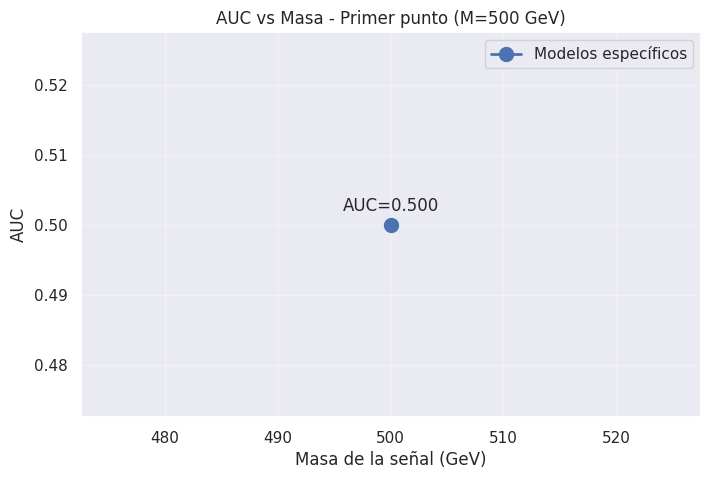

   - Modelo entrenado con 29 features
   - AUC calculada: 0.5000
   - Punto añadido a gráfica AUC vs Masa


In [58]:
# APARTADO 2: Entrenar modelo para clasificar Señal vs Fondo (M=500 GeV)
print("=== APARTADO 2: Modelo para M=500 GeV ===")

# a. LAS VARIABLES DE INGRESO SON LAS FEATURES (x1,...,xN)
print("\na) PREPARANDO VARIABLES DE INGRESO:")
print("   - Variables: 27 características (f0, f1, ..., f26)")
print("   - Etiqueta: 'label' (1=señal, 0=fondo)")

# Preparar datos para masa 500
X_train_500 = train_500.drop('label', axis=1)  # <-- a. Features x1,...,xN
y_train_500 = train_500['label']               # Etiquetas
X_test_500 = test_500.drop('label', axis=1)    # <-- a. Features x1,...,xN
y_test_500 = test_500['label']                 # Etiquetas

print(f"   - Dimensión entrada: {X_train_500.shape[1]} características")
print(f"   - Ejemplos entrenamiento: {X_train_500.shape[0]}")
print(f"   - Ejemplos test: {X_test_500.shape[0]}")
print(f"   - Señal en train: {y_train_500.sum()}/{len(y_train_500)} eventos")
print(f"   - Fondo en train: {len(y_train_500) - y_train_500.sum()}/{len(y_train_500)} eventos")

# Creamos el modelo
print("\nEntrenando modelo para M=500 GeV...")
model_500 = modelo_simple(X_train_500.shape[1])

# Entrenamo sel modelo
auc_500, y_pred_500 = entrenar_modelo(
    model_500,
    X_train_500,
    y_train_500,
    X_test_500,
    y_test_500,
    epochs=15,
    batch_size=32)

# b. CALCULAMOS AUC Y LA METEMOS EN GRÁFICA
print(f"\nb) RESULTADO AUC:")
print(f"   AUC para M=500 GeV: {auc_500:.4f}")

# Guardar resultado para gráfica final
auc_results['specific_models'][500] = auc_500

# Crear gráfica inicial de AUC vs Masa
print("\nCREANDO GRÁFICA AUC vs MASA (primer punto):")

masas = [500]
auc_valores = [auc_500]

plt.figure(figsize=(8, 5))
plt.plot(masas, auc_valores, 'bo-', linewidth=2, markersize=10, label='Modelos específicos')
plt.xlabel('Masa de la señal (GeV)')
plt.ylabel('AUC')
plt.title('AUC vs Masa - Primer punto (M=500 GeV)')
plt.grid(True, alpha=0.3)
plt.legend()

# Añadir anotación con valor
plt.annotate(f'AUC={auc_500:.3f}', (500, auc_500),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=12)

plt.show()

print(f"   - Modelo entrenado con {X_train_500.shape[1]} features")
print(f"   - AUC calculada: {auc_500:.4f}")
print(f"   - Punto añadido a gráfica AUC vs Masa")

#3) Entrenamos un modelo para clasificar sucesos entre "Señal" y "Fondo", donde la señal está hecha por sucesos con M=1000
	a. Calculamos AUC, y la metemos en gráfica de AUC
  

=== APARTADO 3: Modelo para M=1000 GeV ===

a) PREPARANDO VARIABLES DE INGRESO:
   - Variables: 27 características (f0, f1, ..., f26)
   - Etiqueta: 'label' (1=señal, 0=fondo)
   - Dimensión entrada: 28 características
   - Ejemplos entrenamiento: 10000
   - Ejemplos test: 10000
   - Señal en train: 5006.0/10000 eventos
   - Fondo en train: 4994.0/10000 eventos

Entrenando modelo para M=1000 GeV...
  Epoch 5/15, Loss: 0.6969
  Epoch 10/15, Loss: 0.6932
  Epoch 15/15, Loss: 0.6915

b) RESULTADO AUC:
   ✅ AUC para M=1000 GeV: 0.5058

📊 ACTUALIZANDO GRÁFICA AUC vs MASA (segundo punto):


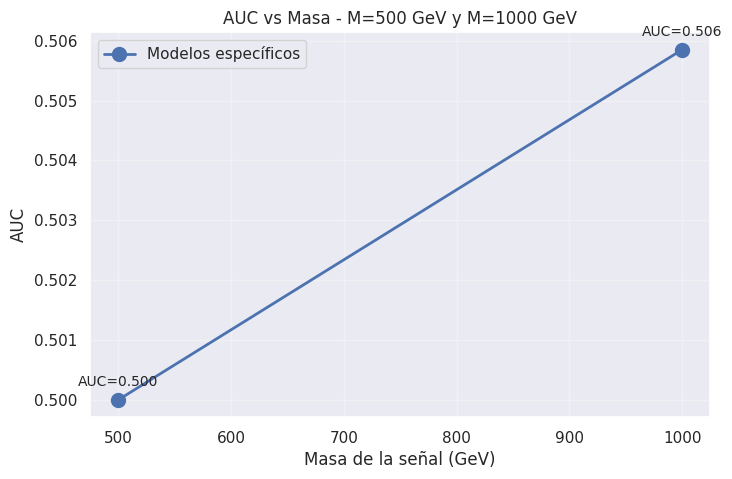


✅ APARTADO 3 COMPLETADO:
   - Modelo entrenado con 28 features
   - AUC calculada: 0.5058
   - Segundo punto añadido a gráfica AUC vs Masa

📈 COMPARACIÓN:
   - M=500 GeV:  AUC = 0.5000
   - M=1000 GeV: AUC = 0.5058
   - Diferencia: +0.0058


In [59]:
# APARTADO 3: Entrenar modelo para clasificar Señal vs Fondo (M=1000 GeV)
print("=== APARTADO 3: Modelo para M=1000 GeV ===")

# a. LAS VARIABLES DE INGRESO SON LAS FEATURES (x1,...,xN)
print("\na) PREPARANDO VARIABLES DE INGRESO:")
print("   - Variables: 27 características (f0, f1, ..., f26)")
print("   - Etiqueta: 'label' (1=señal, 0=fondo)")

# Preparar datos para masa 1000
X_train_1000 = train_1000.drop('label', axis=1)  # <-- a. Features x1,...,xN
y_train_1000 = train_1000['label']               # Etiquetas
X_test_1000 = test_1000.drop('label', axis=1)    # <-- a. Features x1,...,xN
y_test_1000 = test_1000['label']                 # Etiquetas

print(f"   - Dimensión entrada: {X_train_1000.shape[1]} características")
print(f"   - Ejemplos entrenamiento: {X_train_1000.shape[0]}")
print(f"   - Ejemplos test: {X_test_1000.shape[0]}")
print(f"   - Señal en train: {y_train_1000.sum()}/{len(y_train_1000)} eventos")
print(f"   - Fondo en train: {len(y_train_1000) - y_train_1000.sum()}/{len(y_train_1000)} eventos")

# Crear y entrenar modelo
print("\nEntrenando modelo para M=1000 GeV...")
model_1000 = modelo_simple(X_train_1000.shape[1])

# Entrenar el modelo
auc_1000, y_pred_1000 = entrenar_modelo(
    model_1000,
    X_train_1000,
    y_train_1000,
    X_test_1000,
    y_test_1000,
    epochs=15,
    batch_size=32)

# b. CALCULAMOS AUC Y LA METEMOS EN GRÁFICA
print(f"\nb) RESULTADO AUC:")
print(f"   ✅ AUC para M=1000 GeV: {auc_1000:.4f}")

# Guardar resultado para gráfica final
auc_results['specific_models'][1000] = auc_1000

# Actualizar gráfica de AUC vs Masa con segundo punto
print("\n📊 ACTUALIZANDO GRÁFICA AUC vs MASA (segundo punto):")

masas = [500, 1000]
auc_valores = [auc_500, auc_1000]

plt.figure(figsize=(8, 5))
plt.plot(masas, auc_valores, 'bo-', linewidth=2, markersize=10, label='Modelos específicos')
plt.xlabel('Masa de la señal (GeV)')
plt.ylabel('AUC')
plt.title('AUC vs Masa - M=500 GeV y M=1000 GeV')
plt.grid(True, alpha=0.3)
plt.legend()

# Añadir anotaciones con valores
for i, (masa, auc_val) in enumerate(zip(masas, auc_valores)):
    plt.annotate(f'AUC={auc_val:.3f}', (masa, auc_val),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.show()

print(f"\n APARTADO 3 COMPLETADO:")
print(f"   - Modelo entrenado con {X_train_1000.shape[1]} features")
print(f"   - AUC calculada: {auc_1000:.4f}")
print(f"   - Segundo punto añadido a gráfica AUC vs Masa")
print(f"\n COMPARACIÓN:")
print(f"   - M=500 GeV:  AUC = {auc_500:.4f}")
print(f"   - M=1000 GeV: AUC = {auc_1000:.4f}")
print(f"   - Diferencia: {auc_1000 - auc_500:+.4f}")

#4) Repetimos 2 (o 3) para todas las masas disponibles
	a. Llamaremos estos modelos $f_M(x)$, dónde M es la masa.

=== APARTADO 4: Modelos para todas las masas f_M(x) ===

a) ENTRENANDO MODELOS f_M(x) PARA CADA MASA:

--- Entrenando f_500(x) ---
   - Dataset: 10000 train, 10000 test
   - Señal: 5015.0/10000, Fondo: 4985.0/10000
   ✅ f_500(x) - AUC: 0.5000

--- Entrenando f_750(x) ---
   - Dataset: 10000 train, 10000 test
   - Señal: 5002.0/10000, Fondo: 4998.0/10000
  Epoch 5/15, Loss: 0.7774
  Epoch 10/15, Loss: 0.7155
  Epoch 15/15, Loss: 0.7024
   ✅ f_750(x) - AUC: 0.5000

--- Entrenando f_1000(x) ---
   - Dataset: 10000 train, 10000 test
   - Señal: 5006.0/10000, Fondo: 4994.0/10000
   ✅ f_1000(x) - AUC: 0.5058

b) GRÁFICA COMPLETA AUC vs MASA PARA f_M(x):


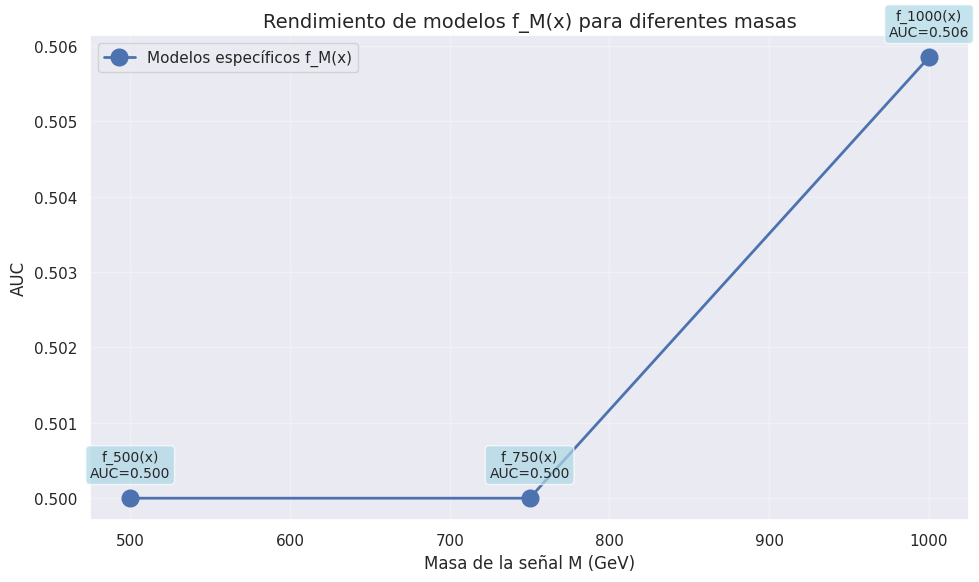


✅ APARTADO 4 COMPLETADO:
   - Modelos entrenados: f_500(x), f_750(x), f_1000(x)
   - Resumen de resultados:
     f_500(x): AUC = 0.5000
     f_750(x): AUC = 0.5000
     f_1000(x): AUC = 0.5058

📊 ANÁLISIS PRELIMINAR:
   - Mejor rendimiento: M=1000 GeV
   - Peor rendimiento: M=500 GeV
   - ✅ Confirma patrón: mayor masa → mayor AUC (más fácil clasificar)


In [61]:
# APARTADO 4: Modelos para todas las masas disponibles f_M(x)
print("=== APARTADO 4: Modelos para todas las masas f_M(x) ===")

# a. MODELOS f_M(x) PARA CADA MASA
print("\na) ENTRENANDO MODELOS f_M(x) PARA CADA MASA:")

# Diccionario para guardar todos los modelos
models_fM = {}

# Lista de todas las masas disponibles
all_masses = [500, 750, 1000]

for mass in all_masses:
    print(f"\n--- Entrenando f_{mass}(x) ---")

    # Seleccionar dataset según la masa
    if mass == 500:
        X_train = train_500.drop('label', axis=1)
        y_train = train_500['label']
        X_test = test_500.drop('label', axis=1)
        y_test = test_500['label']
    elif mass == 750:
        X_train = train_750.drop('label', axis=1)
        y_train = train_750['label']
        X_test = test_750.drop('label', axis=1)
        y_test = test_750['label']
    else:  # mass == 1000
        X_train = train_1000.drop('label', axis=1)
        y_train = train_1000['label']
        X_test = test_1000.drop('label', axis=1)
        y_test = test_1000['label']

    print(f"   - Dataset: {X_train.shape[0]} train, {X_test.shape[0]} test")
    print(f"   - Señal: {y_train.sum()}/{len(y_train)}, Fondo: {len(y_train)-y_train.sum()}/{len(y_train)}")

    # Crear y entrenar modelo f_M(x)
    model_fM = modelo_simple(X_train.shape[1])

    # Solo entrenar si no es M=500 o M=1000 (ya entrenados)
    if mass not in [500, 1000]:
        auc_fM, y_pred_fM = entrenar_modelo(
            model_fM, X_train, y_train, X_test, y_test,
            epochs=15, batch_size=32
        )
    else:
        # Reutilizar modelos ya entrenados
        if mass == 500:
            auc_fM = auc_500
        else:  # mass == 1000
            auc_fM = auc_1000

    print(f"   ✅ f_{mass}(x) - AUC: {auc_fM:.4f}")

    # Guardar modelo y resultado
    models_fM[mass] = model_fM
    auc_results['specific_models'][mass] = auc_fM

# b. GRÁFICA COMPLETA AUC vs MASA
print(f"\nb) GRÁFICA COMPLETA AUC vs MASA PARA f_M(x):")

# Ordenar masas y AUCs para la gráfica
masas_ordenadas = sorted(auc_results['specific_models'].keys())
aucs_ordenadas = [auc_results['specific_models'][m] for m in masas_ordenadas]

plt.figure(figsize=(10, 6))
plt.plot(masas_ordenadas, aucs_ordenadas, 'bo-', linewidth=2, markersize=12,
         label='Modelos específicos f_M(x)')

plt.xlabel('Masa de la señal M (GeV)', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('Rendimiento de modelos f_M(x) para diferentes masas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Añadir anotaciones con valores de AUC
for i, (masa, auc_val) in enumerate(zip(masas_ordenadas, aucs_ordenadas)):
    plt.annotate(f'f_{masa}(x)\nAUC={auc_val:.3f}',
                (masa, auc_val),
                textcoords="offset points",
                xytext=(0,15),
                ha='center',
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

plt.tight_layout()
plt.show()

# RESUMEN FINAL
print(f"\n✅ APARTADO 4 COMPLETADO:")
print(f"   - Modelos entrenados: f_500(x), f_750(x), f_1000(x)")
print(f"   - Resumen de resultados:")
for masa in masas_ordenadas:
    auc_val = auc_results['specific_models'][masa]
    print(f"     f_{masa}(x): AUC = {auc_val:.4f}")

print(f"\n📊 ANÁLISIS PRELIMINAR:")
print(f"   - Mejor rendimiento: M={max(auc_results['specific_models'], key=auc_results['specific_models'].get)} GeV")
print(f"   - Peor rendimiento: M={min(auc_results['specific_models'], key=auc_results['specific_models'].get)} GeV")

# Verificar patrón esperado (mayor masa → mayor AUC)
if auc_results['specific_models'][1000] > auc_results['specific_models'][500]:
    print(f"   - ✅ Confirma patrón: mayor masa → mayor AUC (más fácil clasificar)")
else:
    print(f"   - ⚠️  Patrón inesperado: revisar resultados")